# Low-$\mathcal R$ cutoff of a population of sources

## 1. Propagator of a single source w/ isotropic diffusion

Following arXiv:2608.22374, Appendix A. See also arXiv:1105.4521.


In [1]:
import numpy as np
from astropy import units as u
from astropy.visualization import quantity_support
from matplotlib import pyplot as plt

quantity_support()

<astropy.visualization.units.quantity_support.<locals>.MplQuantityConverterFormatted at 0x113736e40>

In [2]:
from dataclasses import dataclass


@dataclass
class CRSource:
    D0: u.Quantity[u.cm**2 / u.s] = 6e28 * u.cm**2 / u.s
    delta = 1 / 3

    H: u.Quantity[u.kpc] = 7 * u.kpc
    z_s: u.Quantity[u.kpc] = 0 * u.kpc
    x_s: u.Quantity[u.kpc] = 0 * u.kpc
    y_s: u.Quantity[u.kpc] = 0 * u.kpc

    mirror_sources_count: int = 10

    def D(self, R: u.Quantity[u.GV]) -> u.Quantity[u.cm**2 / u.s]:
        return self.D0 * (R / (4 * u.V)) ** self.delta

    def _V_term(
        self,
        z: u.Quantity[u.kpc],
        tau: u.Quantity[u.Myr],
        R: u.Quantity[u.GV],
        z_virt_source: u.Quantity[u.kpc],
    ):
        return np.exp(-((z - z_virt_source) ** 2) / (4 * self.D(R) * tau))

    def V(
        self,
        z: u.Quantity[u.kpc],
        tau: u.Quantity[u.Myr],
        R: u.Quantity[u.GV],
    ):
        components = []
        for n in np.arange(-self.mirror_sources_count, self.mirror_sources_count + 1):
            components.append(self._V_term(z, tau, R, z_virt_source=self.z_s + 4 * self.H * n))
            components.append(
                -self._V_term(z, tau, R, z_virt_source=(2 * self.H - self.z_s) + 4 * self.H * n)
            )
        return np.sum(components, axis=0)

    def P(
        self,
        x: u.Quantity[u.kpc],
        y: u.Quantity[u.kpc],
        z: u.Quantity[u.kpc],
        R: u.Quantity[u.GV],
        tau: u.Quantity[u.Myr],
    ):
        sigma2 = 2 * np.pi * self.D(R) * tau
        return (
            np.exp(-((x - self.x_s) ** 2 + (y - self.y_s) ** 2) / (2 * sigma2))
            / (2 * sigma2) ** (3 / 2)
            * self.V(z, tau, R)
        )

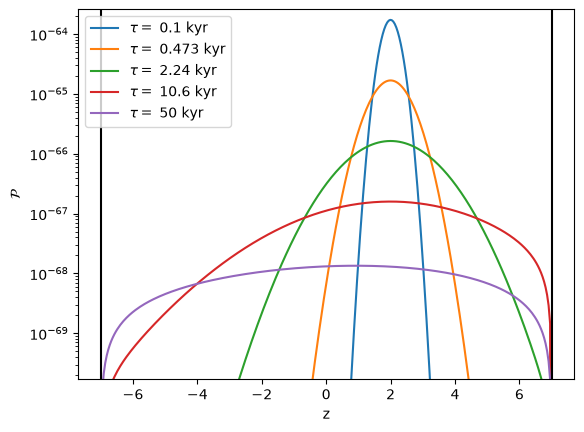

In [3]:
source = CRSource(z_s=2 * u.kpc)

z_grid = np.linspace(-source.H, source.H, 300)
fig, ax = plt.subplots()

Ps = []
for tau in np.geomspace(1e-1, 50, 5) * u.kyr:
    P_ = source.P(0, 0, z_grid, R=10 * u.GV, tau=tau)
    Ps.append(P_)
    ax.plot(z_grid, P_.to(1 / u.cm**3), label=f"$\\tau = $ {tau:.3g}")

Pmax = max([P_.max() for P_ in Ps])
ax.set_ylim(Pmax / 1e6, Pmax * 1.5)
ax.set_yscale("log")
ax.set_xlabel("z")
ax.set_ylabel("$\\mathcal{P}$")
ax.axvline(-source.H, color="k")
ax.axvline(source.H, color="k")
ax.legend()

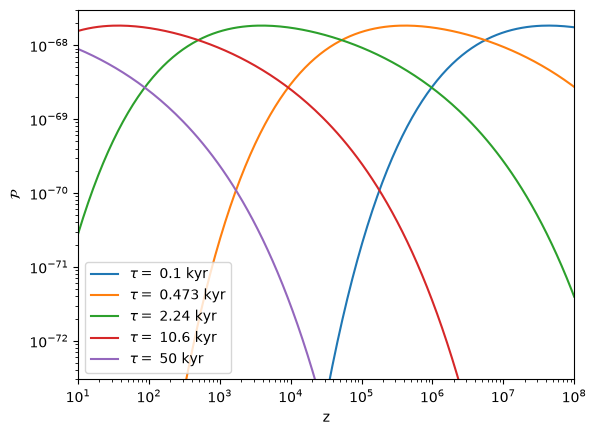

In [7]:
source = CRSource(x_s=4 * u.kpc, z_s=1 * u.kpc, mirror_sources_count=100)

R_grid = np.geomspace(1e1, 1e8, 200) * u.GV

fig, ax = plt.subplots()

Ps = []
for tau in np.geomspace(1e-1, 50, 5) * u.kyr:
    P_ = source.P(0, 8 * u.kpc, 0, R=R_grid, tau=tau)
    Ps.append(P_)
    ax.loglog(R_grid, P_.to(1 / u.cm**3), label=f"$\\tau = $ {tau:.3g}")

Pmax = max([P_.max() for P_ in Ps])
ax.set_ylim(Pmax / 1e10, Pmax * 3)
ax.set_yscale("log")
ax.set_xlabel("z")
ax.set_ylabel("$\\mathcal{P}$")
ax.set_xlim(R_grid[0], R_grid[-1])
ax.set_ylim(3e-73, 3e-68)
ax.legend()